## 1. Package Installation

Ensure that the `engressionts` package is installed in your environment before proceeding.

In [1]:
%pip install gluonts lightning
!pip install -q git+https://github.com/anushatomar13/engressionts.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.0/864.0 kB 23.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 48.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 23.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.8 MB/s eta 0:00:00


## 2. Global Setup & Imports

All necessary libraries are imported here. We also set a global deterministic seed to ensure that our probabilistic trajectories remain fully reproducible.

In [41]:
# 1. Standard Library Imports
import os
import gc
import time
import logging
import warnings
import random
import sys

# 2. Third-Party Data & ML Imports
import numpy as np
import pandas as pd
import torch
import lightning.pytorch as pl
from torch.utils.data import DataLoader

# 3. EngressionTS Imports
from engressionts.models import (
    EnBlockRNNModel,
    EnHiTSModel,
    EnTiDEModel,
    EnTSMixerModel,
)


# 4. Global Configurations
warnings.filterwarnings("ignore")

logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger(__name__)

# 5. Reproducibility / Seeding
SEED = 42
pl.seed_everything(SEED, workers=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)
DEVICE = torch.device("cuda")

Seed set to 42


## 3. Strict Determinism Enforcement

Deep-level strict seeding for completely deterministic GPU operations.

In [18]:
import os
import random
os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
# optional for debugging only:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


class Deterministic:
    def __init__(self):
        pass

    def init_all(self, seed=0, disable_list=['cuda_block']):
        random.seed(seed)
        os.environ['PYTHONHASHSEED'] = str(seed)
        os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
        if 'cuda_block' not in disable_list: # stuck when train deberta
            os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)  
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        if 'torch_deter_algo' not in disable_list: # consumn more gpu sometimes
            torch.use_deterministic_algorithms(True, warn_only=True)


deterministic = Deterministic()

In [19]:

import torch.nn as nn
from typing import Tuple, Optional
from darts import TimeSeries
from darts.metrics import mae, rmse, smape, mase, rmsse
from darts.dataprocessing.transformers import Scaler


In [20]:
dataset_name = "solar_nips"

In [21]:
PRED_LEN = 24
LAGS = (1, 24, 168)

## 4. Data Loading & Preprocessing

We load the dataset and format it into multivariate Darts `TimeSeries` objects. We also compute relevant temporal covariates (e.g. hour-of-day).

In [23]:
from gluonts.dataset.repository.datasets import get_dataset
from gluonts.dataset.multivariate_grouper import MultivariateGrouper


def gluonts_item_to_darts_mv(item, freq: str) -> TimeSeries:
    # GluonTS start is often a pandas Period; convert safely
    start = item["start"].to_timestamp() if hasattr(item["start"], "to_timestamp") else pd.Timestamp(item["start"])

    # GluonTS multivariate target is typically shape (D, T)
    target = np.asarray(item["target"])
    if target.ndim != 2:
        raise ValueError(f"Expected multivariate target with ndim=2, got shape {target.shape}")

    values = target.T  # Darts expects (T, D)
    times = pd.date_range(start=start, periods=values.shape[0], freq=freq)
    cols = [f"dim_{i}" for i in range(values.shape[1])]

    return TimeSeries.from_times_and_values(times, values, columns=cols)

# Load dataset
ds = get_dataset(dataset_name, regenerate=False)
freq = ds.metadata.freq

# Determine number of rolling test windows
train_list = list(ds.train)
test_list  = list(ds.test)
num_test_dates = len(test_list) // len(train_list) 

# Group into multivariate series 
target_dim = int(ds.metadata.feat_static_cat[0].cardinality) 
train_grouper = MultivariateGrouper(max_target_dim=target_dim)
test_grouper  = MultivariateGrouper(num_test_dates=num_test_dates, max_target_dim=target_dim)

train_mv_items = list(train_grouper(train_list))   # usually 1 item
test_mv_items  = list(test_grouper(test_list))     # usually num_test_dates items (7)

train_ts = gluonts_item_to_darts_mv(train_mv_items[0], freq)
test_ts_list = [gluonts_item_to_darts_mv(it, freq) for it in test_mv_items] 


08:01:12 | INFO | using dataset already processed in path /root/.gluonts/datasets/solar_nips.
08:01:13 | INFO | first/last timestamp found: 2006-01-01 00:00/2006-10-20 00:00
08:01:13 | INFO | group training time series to datasets
08:01:13 | INFO | first/last timestamp found: 2006-01-01 00:00/2006-10-27 00:00
08:01:13 | INFO | group test time series to datasets


In [24]:

y_scaler = Scaler()                     
train_y_sc = y_scaler.fit_transform(train_ts)

from darts import TimeSeries, concatenate

def lag_covs_from_scaled_target(ts_sc: TimeSeries, lags=(1,24,168)) -> TimeSeries:
    shifted = []
    for L in lags:
        s = ts_sc.shift(L).with_columns_renamed(
            ts_sc.components, [f"{c}_lag{L}" for c in ts_sc.components]
        )
        shifted.append(s)

    common = shifted[0]
    for s in shifted[1:]:
        common = common.slice_intersect(s)
    shifted = [s.slice_intersect(common) for s in shifted]
    return concatenate(shifted, axis=1)

def fourier_from_index(idx) -> TimeSeries:
    hour = idx.hour.to_numpy()
    dow  = idx.dayofweek.to_numpy()
    X = np.vstack([
        np.sin(2*np.pi*hour/24.0),
        np.cos(2*np.pi*hour/24.0),
        np.sin(2*np.pi*dow/7.0),
        np.cos(2*np.pi*dow/7.0),
    ]).T
    return TimeSeries.from_times_and_values(idx, X, columns=["h_sin","h_cos","dow_sin","dow_cos"])

def dim_indicator_norm(idx, D: int) -> TimeSeries:
    v = (np.arange(D, dtype=np.float32) / (D-1)).astype(np.float32)  # 0..1
    X = np.tile(v, (len(idx), 1))
    cols = [f"dim_id_{i}" for i in range(D)]
    return TimeSeries.from_times_and_values(idx, X, columns=cols)

def build_past_covs_552(ts_sc: TimeSeries, lags=(1,24,168)) -> TimeSeries:
    lag_covs = lag_covs_from_scaled_target(ts_sc, lags)
    idx = lag_covs.time_index
    time_covs = fourier_from_index(idx)
    dim_covs  = dim_indicator_norm(idx, ts_sc.width)
    return concatenate([lag_covs, dim_covs, time_covs], axis=1)


def ts_upto(ts, end_time):
    # Newer Darts
    if hasattr(ts, "slice_end"):
        return ts.slice_end(end_time)
    # Some versions
    if hasattr(ts, "drop_after"):
        return ts.drop_after(end_time)
    if hasattr(ts, "split_after"):
        return ts.split_after(end_time)[0]
    # Works in basically all versions
    return ts.slice(ts.start_time(), end_time)


In [25]:

def gluon_to_wide_df(dataset):
    series_list = []
    
    for i, entry in enumerate(dataset):
        # 1. Create the time index using the start date and frequency
        idx = pd.date_range(
            start=entry["start"].to_timestamp(), 
            periods=len(entry["target"]), 
            freq=entry["start"].freqstr
        )
        
        # 2. Create a Series for each node, named by its index (0 to 136)
        series = pd.Series(entry["target"], index=idx, name=f"node_{i}")
        series_list.append(series)
    
    # 3. Concatenate all series into one DataFrame (T x N)
    return pd.concat(series_list, axis=1)

# Usage:
dataset = get_dataset(dataset_name, regenerate=False)
df_train = gluon_to_wide_df(dataset.train)

def get_7_test_windows(dataset, num_nodes=137):
    all_series = []
    
    # 1. Convert everything to a list of Series first
    for entry in dataset:
        idx = pd.date_range(
            start=entry["start"].to_timestamp(), 
            periods=len(entry["target"]), 
            freq=entry["start"].freqstr
        )
        # Give them a generic name for now
        all_series.append(pd.Series(entry["target"], index=idx))
    
    # 2. Split the list into 7 chunks of 137
    # This assumes the order is [Node0_W1, Node1_W1... Node136_W1, Node0_W2...]
    num_windows = len(all_series) // num_nodes
    windows = []
    
    for w in range(num_windows):
        start_idx = w * num_nodes
        end_idx = (w + 1) * num_nodes
        
        # Grab 137 series and concat them side-by-side
        window_df = pd.concat(all_series[start_idx:end_idx], axis=1)
        
        # Rename columns to node_0, node_1... node_136
        window_df.columns = [f"node_{i}" for i in range(num_nodes)]
        windows.append(window_df)
        
    return windows

# Execute
test_windows = get_7_test_windows(dataset.test, num_nodes=137)


08:08:42 | INFO | using dataset already processed in path /root/.gluonts/datasets/solar_nips.


In [27]:
def impute_seasonal_mean(df, m: int) -> TimeSeries:
    """
    Imputes NaN values in a Darts TimeSeries of shape T x N using the seasonal mean.
    
    Parameters:
    - ts: The original Darts TimeSeries object.
    - m: The seasonal period (e.g., 12 for monthly data, 24 for hourly data).
    
    Returns:
    - A new TimeSeries with NaN values imputed, preserving original metadata.
    """
    
    # 2. Create a seasonal indicator array (0 to m-1) 
    # This works reliably because Darts enforces a strictly regular time index
    season_indicator = np.arange(len(df)) % m
    
    # 3. Group by the season, calculate the mean per column, and fill NaNs
    # transform('mean') broadcasts the group means back to the original index shape
    df_imputed = df.fillna(df.groupby(season_indicator).transform('mean'))
    
    # 4. Inject the values back into the TimeSeries to retain metadata
    return df_imputed


df_train = impute_seasonal_mean(df_train, m=24)


## 5. Evaluation Metrics

Define the PyTorch-based metrics used for point forecasting accuracy (MAE, RMSE, sMAPE) and probabilistic calibration (CRPS).

In [28]:


# Utility functions
def _sync_tensors(*args):
    """
    Converts inputs to PyTorch tensors and synchronizes them to the same device.
    Uses the device of the first tensor found.
    """
    tensors = [
        torch.as_tensor(x) if not isinstance(x, torch.Tensor) else x
        for x in args
    ]

    if not tensors:
        return []

    device = tensors[0].device
    return [t.to(device, dtype=torch.float32) for t in tensors]

def _get_point_forecast(y_pred, point_method):
    """
    Collapses the sample dimension (dim=-1) to generate a point forecast.
    """
    if point_method == "mean":
        return torch.mean(y_pred, dim=-1)

    elif point_method == "median":
        return torch.median(y_pred, dim=-1).values

    elif isinstance(point_method, float) and 0.0 <= point_method <= 1.0:
        return torch.quantile(y_pred, point_method, dim=-1)

    else:
        raise ValueError(
            "point_method must be 'mean', 'median', "
            "or a float between 0.0 and 1.0"
        )

def _aggregate(tensor, method):
    """
    Aggregates the tensor over the remaining dimensions.
    """
    if method is None or method == "none":
        return tensor

    elif method == "mean":
        return torch.mean(tensor)

    elif method == "median":
        return torch.median(tensor)

    elif method == "sum":
        return torch.sum(tensor)

    elif method == "norm":
        return torch.norm(tensor)

    else:
        raise ValueError(f"Unsupported aggregate_method: {method}")

def _format_return(tensor):
    return tensor.item() if tensor.numel() == 1 else tensor

# Point metrics
def mae(y_true, y_pred, point_method="mean", aggregate_method="mean"):
    """
    Mean Absolute Error (MAE).

    .. math::
        \\text{MAE} = \\frac{1}{N} \\sum_{i=1}^{N} |y_i - \\hat{y}_i|
    """
    y_true, y_pred = _sync_tensors(y_true, y_pred)
    y_point = _get_point_forecast(y_pred, point_method)

    error = torch.abs(y_true - y_point)

    return _format_return(
        _aggregate(error, aggregate_method)
    )

def mse(y_true, y_pred, point_method="mean", aggregate_method="mean"):
    """
    Mean Squared Error (MSE).

    .. math::
        \\text{MSE} = \\frac{1}{N} \\sum_{i=1}^{N} (y_i - \\hat{y}_i)^2
    """
    y_true, y_pred = _sync_tensors(y_true, y_pred)
    y_point = _get_point_forecast(y_pred, point_method)

    error = (y_true - y_point) ** 2

    return _format_return(
        _aggregate(error, aggregate_method)
    )

def rmse(y_true, y_pred, point_method="mean", aggregate_method="mean"):
    """
    Root Mean Squared Error (RMSE).

    .. math::
        \\text{RMSE} =
        \\sqrt{
            \\frac{1}{N}
            \\sum_{i=1}^{N}
            (y_i - \\hat{y}_i)^2
        }
    """
    y_true, y_pred = _sync_tensors(y_true, y_pred)
    y_point = _get_point_forecast(y_pred, point_method)

    # Calculate squared error
    squared_error = (y_true - y_point) ** 2

    # Aggregate (e.g., take the mean) FIRST
    agg_error = _aggregate(squared_error, aggregate_method)

    # Take the square root of the aggregated value
    return _format_return(torch.sqrt(agg_error))

def mape(
    y_true,
    y_pred,
    point_method="mean",
    aggregate_method="mean",
    eps=1e-8
):
    """
    Mean Absolute Percentage Error (MAPE).

    .. math::
        \\text{MAPE} =
        \\frac{100}{N}
        \\sum_{i=1}^{N}
        \\left|
        \\frac{y_i - \\hat{y}_i}{\\max(|y_i|, \\epsilon)}
        \\right|
    """
    y_true, y_pred = _sync_tensors(y_true, y_pred)
    y_point = _get_point_forecast(y_pred, point_method)

    error = torch.abs(
        (y_true - y_point)
        / torch.clamp(torch.abs(y_true), min=eps)
    )

    return _format_return(
        _aggregate(error * 100, aggregate_method)
    )

def smape(
    y_true,
    y_pred,
    point_method="mean",
    aggregate_method="mean",
    eps=1e-8
):
    """
    Symmetric Mean Absolute Percentage Error (sMAPE).

    .. math::
        \\text{sMAPE} =
        \\frac{100}{N}
        \\sum_{i=1}^{N}
        \\frac{|y_i - \\hat{y}_i|}
        {\\max((|y_i| + |\\hat{y}_i|) / 2, \\epsilon)}
    """
    y_true, y_pred = _sync_tensors(y_true, y_pred)
    y_point = _get_point_forecast(y_pred, point_method)

    num = torch.abs(y_point - y_true)

    denom = torch.clamp(
        (torch.abs(y_true) + torch.abs(y_point)) / 2,
        min=eps
    )

    return _format_return(
        _aggregate((num / denom) * 100, aggregate_method)
    )

def smdape(
    y_true,
    y_pred,
    point_method="mean",
    aggregate_method="mean",
    eps=1e-8
):
    """
    Symmetric Median Absolute Percentage Error (sMdAPE).

    .. math::
        \\text{sMdAPE} =
        \\text{median}
        \\left(
        100 \\times
        \\frac{|y_i - \\hat{y}_i|}
        {\\max((|y_i| + |\\hat{y}_i|) / 2, \\epsilon)}
        \\right)
    """
    y_true, y_pred = _sync_tensors(y_true, y_pred)
    y_point = _get_point_forecast(y_pred, point_method)

    num = torch.abs(y_point - y_true)

    denom = torch.clamp(
        (torch.abs(y_true) + torch.abs(y_point)) / 2,
        min=eps
    )

    error = (num / denom) * 100

    return _format_return(
        _aggregate(
            error,
            "median" if aggregate_method != "none" else "none"
        )
    )

def mpe(
    y_true,
    y_pred,
    point_method="mean",
    aggregate_method="mean",
    eps=1e-8
):
    """
    Mean Percentage Error (MPE).

    .. math::
        \\text{MPE} =
        \\frac{100}{N}
        \\sum_{i=1}^{N}
        \\frac{y_i - \\hat{y}_i}
        {\\max(y_i, \\epsilon)}
    """
    y_true, y_pred = _sync_tensors(y_true, y_pred)
    y_point = _get_point_forecast(y_pred, point_method)

    error = (
        (y_true - y_point)
        / torch.clamp(y_true, min=eps)
    )

    return _format_return(
        _aggregate(error * 100, aggregate_method)
    )

def opl(y_true, y_pred, point_method="mean", aggregate_method="mean"):
    """
    Optimized Point Loss (OPL). Measures if the model correctly predicted
    the direction of change compared to the last observation.

    .. math::
        \\text{OPL} =
        \\frac{1}{2N}
        \\sum_{t=1}^{N}
        |
        \\text{sgn}(y_{t+1} - y_t)
        -
        \\text{sgn}(\\hat{y}_{t+1} - y_t)
        |
    """
    y_true, y_pred = _sync_tensors(y_true, y_pred)
    y_point = _get_point_forecast(y_pred, point_method)

    diff_true = torch.sign(
        y_true[1:] - y_true[:-1]
    )

    diff_pred = torch.sign(
        y_point[1:] - y_true[:-1]
    )

    error = torch.abs(diff_true - diff_pred) / 2

    return _format_return(
        _aggregate(error, aggregate_method)
    )

def mase(
    y_true,
    y_pred,
    y_train,
    point_method="mean",
    aggregate_method="mean",
    eps=1e-8
):
    """
    Mean Absolute Scaled Error (MASE).

    .. math::
        \\text{MASE} =
        \\frac{
            \\frac{1}{H}
            \\sum_{t=1}^{H}
            |y_t - \\hat{y}_t|
        }{
            \\max(
                \\frac{1}{T-1}
                \\sum_{t=2}^{T}
                |y_t - y_{t-1}|,
                \\epsilon
            )
        }
    """
    y_true, y_pred, y_train = _sync_tensors(
        y_true,
        y_pred,
        y_train
    )

    y_point = _get_point_forecast(
        y_pred,
        point_method
    )

    # 1. Numerator: MAE of forecast
    abs_err_forecast = torch.abs(
        y_true - y_point
    )

    mae_forecast = torch.nanmean(
        abs_err_forecast,
        dim=0
    )

    # 2. Denominator: MAE of naive in-sample forecast
    diff = torch.abs(
        y_train[1:] - y_train[:-1]
    )

    scale = torch.nanmean(
        diff,
        dim=0
    )

    # 3. Guard against exact zeros or all-NaN series
    scale = torch.clamp(
        scale,
        min=eps
    )

    scale = torch.nan_to_num(
        scale,
        nan=eps
    )

    # 4. Calculate final metric and scrub any resulting NaNs
    mase_per_series = mae_forecast / scale

    mase_per_series = torch.nan_to_num(
        mase_per_series,
        nan=0.0
    )

    return _format_return(
        _aggregate(
            mase_per_series,
            aggregate_method
        )
    )

def rmsse(
    y_true,
    y_pred,
    y_train,
    point_method="mean",
    aggregate_method="mean",
    eps=1e-8
):
    """
    Root Mean Squared Scaled Error (RMSSE).

    .. math::
        \\text{RMSSE} =
        \\sqrt{
            \\frac{
                \\frac{1}{H}
                \\sum_{t=1}^{H}
                (y_t - \\hat{y}_t)^2
            }{
                \\max(
                    \\frac{1}{T-1}
                    \\sum_{t=2}^{T}
                    (y_t - y_{t-1})^2,
                    \\epsilon
                )
            }
        }
    """
    y_true, y_pred, y_train = _sync_tensors(
        y_true,
        y_pred,
        y_train
    )

    y_point = _get_point_forecast(
        y_pred,
        point_method
    )

    # 1. Numerator: MSE of forecast (average over time, dim=0)
    sq_err_forecast = (
        y_true - y_point
    ) ** 2

    mse_forecast = torch.nanmean(
        sq_err_forecast,
        dim=0
    )

    # 2. Denominator: MSE of naive in-sample forecast
    # (average over time, dim=0)
    diff = (
        y_train[1:] - y_train[:-1]
    ) ** 2

    scale = torch.nanmean(
        diff,
        dim=0
    )

    # 3. Guard against exact zeros or all-NaN series
    scale = torch.clamp(
        scale,
        min=eps
    )

    scale = torch.nan_to_num(
        scale,
        nan=eps
    )

    # 4. Calculate final metric and scrub any resulting NaNs
    rmsse_per_series = torch.sqrt(
        mse_forecast / scale
    )

    rmsse_per_series = torch.nan_to_num(
        rmsse_per_series,
        nan=0.0
    )

    return _format_return(
        _aggregate(
            rmsse_per_series,
            aggregate_method
        )
    )

def owa(
    y_true,
    y_pred,
    y_train,
    y_naive_pred=None,
    point_method="mean",
    aggregate_method="mean",
    eps=1e-8
):
    """
    Overall Weighted Average (OWA).

    .. math::
        \\text{OWA} =
        \\frac{1}{2}
        \\left(
            \\frac{\\text{sMAPE}}
            {\\max(\\text{sMAPE}_{naive}, \\epsilon)}
            +
            \\frac{\\text{MASE}}
            {\\max(\\text{MASE}_{naive}, \\epsilon)}
        \\right)
    """
    y_true, y_pred, y_train = _sync_tensors(
        y_true,
        y_pred,
        y_train
    )

    if y_naive_pred is None:
        # Utilize the first point of y_pred across the time dimension
        # (dim=0) and repeat it across to form a naive prediction
        # of identical shape
        y_naive_pred = y_pred[0:1, ...].expand_as(y_pred)

    else:
        y_naive_pred = _sync_tensors(
            y_naive_pred
        )[0]

    smape_val = smape(
        y_true,
        y_pred,
        point_method,
        "none",
        eps
    )

    smape_naive = smape(
        y_true,
        y_naive_pred,
        point_method,
        "none",
        eps
    )

    mase_val = mase(
        y_true,
        y_pred,
        y_train,
        point_method,
        "none",
        eps
    )

    mase_naive = mase(
        y_true,
        y_naive_pred,
        y_train,
        point_method,
        "none",
        eps
    )

    owa_val = (
        0.5 * (
            smape_val
            / torch.clamp(smape_naive, min=eps)
        )
        +
        0.5 * (
            mase_val
            / torch.clamp(mase_naive, min=eps)
        )
    )

    return _format_return(
        _aggregate(
            owa_val,
            aggregate_method
        )
    )

# Probabilistic metrics
def pinball_loss(
    y_true,
    y_pred,
    quantile,
    aggregate_method="mean"
):
    """
    Pinball Loss (Quantile Loss).

    .. math::
        L_q(y, \\hat{y}) =
        \\max(
            q(y - \\hat{y}),
            (q - 1)(y - \\hat{y})
        )
    """
    y_true, y_pred = _sync_tensors(
        y_true,
        y_pred
    )

    y_pred_q = _get_point_forecast(
        y_pred,
        point_method=quantile
    )

    error = y_true - y_pred_q

    loss = torch.max(
        quantile * error,
        (quantile - 1) * error
    )

    return _format_return(
        _aggregate(
            loss,
            aggregate_method
        )
    )

def crps(
    y_true,
    y_pred,
    aggregate_method="mean"
):
    """
    Continuous Ranked Probability Score (CRPS).
    Empirical Approximation.

    .. math::
        \\text{CRPS} =
        \\frac{1}{S}
        \\sum_{s=1}^{S}
        |y - \\hat{y}_s|
        -
        \\frac{1}{2S^2}
        \\sum_{s_1=1}^{S}
        \\sum_{s_2=1}^{S}
        |\\hat{y}_{s_1} - \\hat{y}_{s_2}|
    """
    y_true, y_pred = _sync_tensors(
        y_true,
        y_pred
    )

    y_true_ext = y_true.unsqueeze(-1)

    abs_diff_true = torch.mean(
        torch.abs(y_pred - y_true_ext),
        dim=-1
    )

    y_pred_i = y_pred.unsqueeze(-1)
    y_pred_j = y_pred.unsqueeze(-2)

    abs_diff_samples = torch.mean(
        torch.abs(y_pred_i - y_pred_j),
        dim=(-1, -2)
    )

    crps = (
        abs_diff_true
        - 0.5 * abs_diff_samples
    )

    return _format_return(
        _aggregate(
            crps,
            aggregate_method
        )
    )

def empirical_coverage(
    y_true,
    y_pred,
    alpha=0.1,
    aggregate_method="mean"
):
    """
    Empirical Coverage (Prediction Interval Coverage Probability - PICP).

    .. math::
        \\text{PICP} =
        \\frac{1}{N}
        \\sum_{i=1}^{N}
        \\mathbf{1}(L_i \\leq y_i \\leq U_i)
    """
    y_true, y_pred = _sync_tensors(
        y_true,
        y_pred
    )

    lower = torch.quantile(
        y_pred,
        alpha / 2,
        dim=-1
    )

    upper = torch.quantile(
        y_pred,
        1 - (alpha / 2),
        dim=-1
    )

    inside = (
        (y_true >= lower)
        & (y_true <= upper)
    ).float()

    return _format_return(
        _aggregate(
            inside,
            aggregate_method
        )
    )

def winkler_score(
    y_true,
    y_pred,
    alpha=0.1,
    aggregate_method="mean"
):
    """
    Winkler Score (Mean Interval Score - MIS).

    .. math::
        \\text{MIS} =
        (U_i - L_i)
        +
        \\frac{2}{\\alpha}
        (L_i - y_i)
        \\mathbf{1}(y_i < L_i)
        +
        \\frac{2}{\\alpha}
        (y_i - U_i)
        \\mathbf{1}(y_i > U_i)
    """
    y_true, y_pred = _sync_tensors(
        y_true,
        y_pred
    )

    lower = torch.quantile(
        y_pred,
        alpha / 2,
        dim=-1
    )

    upper = torch.quantile(
        y_pred,
        1 - (alpha / 2),
        dim=-1
    )

    widths = upper - lower

    below = (
        y_true < lower
    ).float()

    above = (
        y_true > upper
    ).float()

    penalty_below = (
        (2 / alpha)
        * (lower - y_true)
        * below
    )

    penalty_above = (
        (2 / alpha)
        * (y_true - upper)
        * above
    )

    scores = (
        widths
        + penalty_below
        + penalty_above
    )

    return _format_return(
        _aggregate(
            scores,
            aggregate_method
        )
    )

def mpiw(
    y_pred,
    alpha=0.1,
    aggregate_method="mean"
):
    """
    Mean Prediction Interval Width (MPIW).

    .. math::
        \\text{MPIW} =
        \\frac{1}{N}
        \\sum_{i=1}^{N}
        (U_i - L_i)
    """
    y_pred = _sync_tensors(y_pred)[0]

    lower = torch.quantile(
        y_pred,
        alpha / 2,
        dim=-1
    )

    upper = torch.quantile(
        y_pred,
        1 - (alpha / 2),
        dim=-1
    )

    widths = upper - lower

    return _format_return(
        _aggregate(
            widths,
            aggregate_method
        )
    )

def rho_risk(
    y_true,
    y_pred,
    quantiles=[0.1, 0.5, 0.9],
    aggregate_method="mean",
    eps=1e-8
):
    """
    Rho-Risk (Normalized Quantile Loss).

    .. math::
        \\rho\\text{-risk} =
        \\frac{
            2 \\sum_i L_q(y_i, \\hat{y}_i)
        }{
            \\max(
                \\sum_i |y_i|,
                \\epsilon
            )
        }
    """
    y_true, y_pred = _sync_tensors(
        y_true,
        y_pred
    )

    total_true = torch.clamp(
        torch.sum(torch.abs(y_true)),
        min=eps
    )

    rho_risks = []

    for q in quantiles:
        p_loss_q = pinball_loss(
            y_true,
            y_pred,
            q,
            aggregate_method="sum"
        )

        rho_risks.append(
            2 * p_loss_q / total_true
        )

    avg_rho_risk = (
        sum(rho_risks)
        / len(rho_risks)
    )

    return _format_return(
        _aggregate(
            avg_rho_risk,
            aggregate_method
        )
    )

In [29]:

import time

def get_metrics(model, test_windows, y_scaler, pred_len=24, lags=(1, 24, 168), 
                num_samples=100, seeds=list(range(40, 51)), point_method="median", 
                quantiles=[0.1, 0.5, 0.9], alpha=0.05):
    all_seed_summaries = []
    
    for seed in seeds:
        window_metrics = []
        y_pred_list = []
        y_true_list = []
        total_inference_time = 0.0

        for i, window_df in enumerate(test_windows):
            full_ts = TimeSeries.from_dataframe(window_df).astype(np.float32)
            full_sc = y_scaler.transform(full_ts).astype(np.float32)
            full_pc = build_past_covs_552(full_sc, lags=lags).astype(np.float32)

            full_sc = full_sc.slice_intersect(full_pc)
            full_ts = full_ts.slice_intersect(full_sc)
            full_pc = full_pc.slice_intersect(full_sc)

            past_true_sc = full_sc[:-pred_len]
            past_true = full_ts[:-pred_len]
            gt_future = full_ts[-pred_len:]

            forecast_start = gt_future.start_time()
            pc_past = ts_upto(full_pc, forecast_start)

            start_time = time.time()

            predict_kwargs = {}
            if getattr(model, "supports_past_covariates", False):
                predict_kwargs["past_covariates"] = pc_past

            fc_sc = model.predict(
                n=pred_len,
                series=past_true_sc,
                num_samples=num_samples,
                verbose=False,
                random_state=seed,
                **predict_kwargs
            )

            inference_time = time.time() - start_time
            total_inference_time += inference_time

            fc = y_scaler.inverse_transform(fc_sc)

            y_pred_raw = fc.all_values(copy=False)
            y_pred_clipped = np.clip(y_pred_raw, a_min=0.0, a_max=None)
            y_pred = y_pred_clipped

            y_true = gt_future.all_values(copy=False).squeeze(-1)
            y_train = past_true.all_values(copy=False).squeeze(-1)

            metrics_dict = {
                "MAE": mae(y_true, y_pred, point_method=point_method),
                "MSE": mse(y_true, y_pred, point_method=point_method),
                "RMSE": rmse(y_true, y_pred, point_method=point_method),
                "MAPE": mape(y_true, y_pred, point_method=point_method),
                "sMAPE": smape(y_true, y_pred, point_method=point_method),
                "sMdAPE": smdape(y_true, y_pred, point_method=point_method),
                "MPE": mpe(y_true, y_pred, point_method=point_method),
                "OPL": opl(y_true, y_pred, point_method=point_method),
                "MASE": mase(y_true, y_pred, y_train, point_method=point_method),
                "RMSSE": rmsse(y_true, y_pred, y_train, point_method=point_method),
                "OWA": owa(y_true, y_pred, y_train, point_method=point_method),
                "PICP": empirical_coverage(y_true, y_pred, alpha=alpha),
                "MIS": winkler_score(y_true, y_pred, alpha=alpha),
                "MPIW": mpiw(y_pred, alpha=alpha),
                "Rho_Risk": rho_risk(y_true, y_pred, quantiles=quantiles),
            }

            window_metrics.append(metrics_dict)
            y_pred_list.append(y_pred_raw)
            y_true_list.append(y_true)

        preds_stacked = []
        targets_stacked = []
        for p_val, t_val in zip(y_pred_list, y_true_list):
            if p_val.ndim == 2:
                p_val = np.expand_dims(p_val, axis=1) # [T, 1, N]
            if t_val.ndim == 1:
                t_val = np.expand_dims(t_val, axis=1) # [T, 1]
            preds_stacked.append(p_val)
            targets_stacked.append(t_val)
            
        preds_raw = np.stack(preds_stacked, axis=0) # [B, T, D, N]
        targets_raw = np.stack(targets_stacked, axis=0) # [B, T, D]
        preds_transposed = np.transpose(preds_raw, (0, 3, 1, 2))
        preds_sum = preds_transposed.sum(axis=-1) # [B, N, T]
        targets_sum = targets_raw.sum(axis=-1) # [B, T]
        
        def crps_benchmark(preds, targets, quantiles=(np.arange(20) / 20.0)[1:]):
            x = np.quantile(preds, quantiles, axis=1, method="nearest")
            quantiles = np.expand_dims(quantiles, axis=list(range(1, len(preds.shape))))
            loss = 2 * np.sum(np.abs((x - targets) * ((targets <= x) - quantiles)), axis=2)
            denominator = np.abs(targets).sum(axis=1).mean()
            return loss.mean() / (denominator + 1e-8)

        crps_value = crps_benchmark(preds_sum, targets_sum, quantiles=(np.arange(20) / 20.0)[1:])

        df_summary = pd.DataFrame(window_metrics).mean().to_frame(name="Average_Score")
        df_summary.loc["Inference Time (s)", "Average_Score"] = total_inference_time / len(test_windows)
        df_summary.loc["CRPS", "Average_Score"] = crps_value
        
        all_seed_summaries.append(df_summary)

    concat_df = pd.concat(all_seed_summaries, axis=1)
    mean_series = concat_df.mean(axis=1).round(3)
    
    # Return clear clean numbers (floats) instead of latex strings
    final_df = mean_series.to_frame(name="Average_Score")


    return final_df


## 6. Model Training & Evaluation Loop

Iterate over our selected `EngressionTS` architectures. For each model, we train it using the Energy Score loss and evaluate its generated probabilistic trajectories.

In [30]:
import logging
import lightning.pytorch as pl
# Lightning 2.x
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

# Older Lightning versions
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)


------

In [44]:
train_pc = build_past_covs_552(train_y_sc)
train_y_sc = train_y_sc.slice_intersect(train_pc)
train_pc   = train_pc.slice_intersect(train_y_sc)
train_pc = train_pc.astype(np.float32)

warnings.filterwarnings("ignore")

# Suppress PyTorch Lightning internal logs
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger(__name__)

# List of all models to run 
MODELS_TO_RUN_RAW = [
    ("EnBlockLSTM", EnBlockRNNModel, {"model": "LSTM"}),
    ("EnHiTSModel", EnHiTSModel, {}),
    ("EnTiDEModel", EnTiDEModel, {}),
    ("EnTSMixerModel", EnTSMixerModel, {}),
]

# Filter out models that were not imported (are None)
MODELS_TO_RUN = [
    (name, cls, kwargs) for name, cls, kwargs in MODELS_TO_RUN_RAW
    if cls is not None
]

pl_trainer_kwargs = {
    "accelerator": "gpu" if DEVICE.type == "cuda" else "cpu",
    "devices": [DEVICE.index] if DEVICE.index is not None else "auto",
    "enable_progress_bar": True,
    "enable_model_summary": False,
}

BASE_KWARGS = {
    "pl_trainer_kwargs": pl_trainer_kwargs,
    "output_chunk_length": PRED_LEN, 
    "num_samples_train": 2,
    "noise_std": 1,
    "optimizer_kwargs": {"lr": 1e-3},
    "random_state": SEED,
    "batch_size": 512,
    "n_epochs": 30,
    "noise_type": "uniform"
}

CSV_FILENAME = "Solar_Engression_Results.csv"

# Load existing results to support resume
if os.path.exists(CSV_FILENAME):
    logger.info(f"Found existing results file '{CSV_FILENAME}'. Loading to resume progress...")
    results_df = pd.read_csv(CSV_FILENAME)
    # Load completed model names
    completed_models = set(results_df["Model"].tolist()) if "Model" in results_df.columns else set()
    all_results = results_df.to_dict(orient="records")
else:
    logger.info("No existing results file found. Starting fresh...")
    completed_models = set()
    all_results = []

trained_models = {}

total_models = len(MODELS_TO_RUN)

for idx, (model_name, model_class, extra_kwargs) in enumerate(MODELS_TO_RUN, 1):
    print(f"\n==============================================")
    print(f"[{idx}/{total_models}] Processing {model_name}...")
    print(f"==============================================\n")
    
    if model_name in completed_models:
        logger.info(f"[{idx}/{total_models}] Skipping {model_name} - already completed.")
        continue
        
    # 1. Clean up GPU memory before starting a new model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # 2. Dynamic Model Configurations
    model_kwargs = BASE_KWARGS.copy()
    model_kwargs.update(extra_kwargs) 
    
    # Dynamically map parameters based on constructor signature to prevent ValueError
    import inspect
    sig = inspect.signature(model_class.__init__)
    if "num_samples_train" not in sig.parameters and "num_samples" in sig.parameters:
        if "num_samples_train" in model_kwargs:
            model_kwargs["num_samples"] = model_kwargs.pop("num_samples_train")
            
    if "num_samples_train" in model_kwargs and "num_samples_train" not in sig.parameters:
        del model_kwargs["num_samples_train"]
        
    model_kwargs["input_chunk_length"] = 30 if model_name == "EnTCNModel" else 24
    
    if model_name == "EnTFTModel":
        model_kwargs["add_relative_index"] = True
        
    if model_name == "EnChronos2Model":
        model_kwargs["batch_size"] = 2 
        
    # 3. Dynamic Fit Configurations
    # Restored verbose=True so Darts actually renders the Lightning progress bar
    fit_kwargs = {
        "verbose": True,
        "dataloader_kwargs": {"num_workers": 15},
    }
    
    # Omit past covariates for models that do not support them
    if model_name in ["EnRNNModel", "EnLSTM", "EnGRU"]:
        pass
    else:
        fit_kwargs["past_covariates"] = train_pc

    try:
        model = model_class(**model_kwargs)

        if not hasattr(model, 'num_samples') and hasattr(model, 'num_samples_train'):
            model.num_samples = model.num_samples_train
        
        logger.info(f"[{idx}/{total_models}] Training {model_name}...")
        start_time = time.time()
        
        model.fit(
            train_y_sc,
            **fit_kwargs
        )
        
        training_time = time.time() - start_time
        logger.info(f"[{idx}/{total_models}] {model_name} trained/initialized in {training_time:.2f} seconds.")
        trained_models[model_name] = model
        
        logger.info(f"[{idx}/{total_models}] Evaluating {model_name}...")
        
        metrics_df = get_metrics(
            model, test_windows, y_scaler, pred_len=PRED_LEN, lags=(1, 24, 168), 
            num_samples=100, seeds=list(range(40, 51)), point_method="median", 
            quantiles=[0.1, 0.5, 0.9], alpha=0.05
        )
        
        # ADDED: Print the clean metrics table directly after evaluation!
        print(f"\n--- Metrics for {model_name} ---")
        display(metrics_df) if 'display' in globals() else print(metrics_df)
        print("-" * 40 + "\n")

        # 4. Restructure results aggregation in tabular format (row-per-model)
        row = {
            "Model": model_name,
            "Batch Size": model_kwargs.get("batch_size", 512),
            "Max Steps/Epochs": model_kwargs.get("n_epochs", 30),
            "Training Samples": model_kwargs.get("num_samples_train", model_kwargs.get("num_samples", 2)),
            "Prediction Samples": 100,
            "Noise Std": model_kwargs.get("noise_std", 1.0),
            "Noise Type": model_kwargs.get("noise_type", "gaussian"),
            "Input Length": model_kwargs.get("input_chunk_length", 24),
            "Forecast Horizon": PRED_LEN,
            "Training Time (s)": training_time,
            "Inference Time (s)": metrics_df.loc["Inference Time (s)", "Average_Score"] if "Inference Time (s)" in metrics_df.index else 0.0,
        }
        
        # Add other metric scores dynamically
        for metric_name in metrics_df.index:
            if metric_name not in ["Inference Time (s)", "Inference Time"]:
                row[metric_name] = metrics_df.loc[metric_name, "Average_Score"]
                
        all_results.append(row)
        
        # Save after every model in tabular format
        results_df = pd.DataFrame(all_results)
        results_df.to_csv(CSV_FILENAME, index=False)
        logger.info(f"[{idx}/{total_models}] Saved results for {model_name} to {CSV_FILENAME}.\n")
        
    except Exception as e:
        logger.error(f"[{idx}/{total_models}] FAILED on {model_name}. Error: {str(e)}\n")
        continue

logger.info(f"Job finished. Final consolidated metrics saved to {CSV_FILENAME}.")


08:45:14 | INFO | No existing results file found. Starting fresh...
08:45:15 | INFO | [1/4] Training EnBlockLSTM...
08:45:15 | INFO | Train dataset contains 5954 samples.
08:45:15 | INFO | Time series values are 32-bits; casting model to float32.



[1/4] Processing EnBlockLSTM...



┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ noise_layer     │ UniformNoise     │      0 │ train │     0 │
│ 6 │ rnn             │ LSTM             │ 71.6 K │ train │     0 │
│ 7 │ fc              │ Sequential       │  3.6 K │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 75.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 75.2 K                                                                                               
Total estimated model params size (MB): 0.301                                                                      
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion           │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion     │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion       │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics       │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics         │ MetricCollection │      0 │ train │     0 │
│ 5 │ noise_layer         │ UniformNoise     │      0 │ train │     0 │
│ 6 │ fc_hist             │ Linear           │    600 │ train │     0 │
│ 7 │ feature_mixing_hist │ _FeatureMixing   │ 95.6 K │ train │     0 │
│ 8 │ conditional_mixer   │ ModuleList       │ 30.1 K │ train │     0 │
│ 9 │ fc_out              │ Linear           │  8.9 K │ train │     0 │
└───┴─────────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 135 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 135 K                                                                                                
Total estimated model params size (MB): 0.541                                                                      
Modules in train mode: 46                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

08:50:45 | INFO | [4/4] EnTSMixerModel trained/initialized in 53.35 seconds.
08:50:45 | INFO | [4/4] Evaluating EnTSMixerModel...
08:51:18 | INFO | [4/4] Saved results for EnTSMixerModel to Solar_Engression_Results2.csv.

08:51:18 | INFO | Job finished. Final consolidated metrics saved to Solar_Engression_Results2.csv.



--- Metrics for EnTSMixerModel ---
                    Average_Score
MAE                  1.727100e+01
MSE                  1.101863e+03
RMSE                 3.129600e+01
MAPE                 7.443771e+09
sMAPE                1.027610e+02
sMdAPE               8.029700e+01
MPE                 -7.443771e+09
OPL                  3.120000e-01
MASE                 1.360000e+00
RMSSE                1.335000e+00
OWA                  9.339748e+08
PICP                 5.940000e-01
MIS                  4.867040e+02
MPIW                 1.316500e+01
Rho_Risk             7.340000e-01
Inference Time (s)   6.800000e-02
CRPS                 4.600000e-01
----------------------------------------



In [45]:
print(list(trained_models.keys()))

['EnBlockLSTM', 'EnHiTSModel', 'EnTiDEModel', 'EnTSMixerModel']


### Predicted vs. Ground Truth

Visualizes the **median forecasts and 95% prediction intervals** against the ground-truth values for the selected models and nodes.

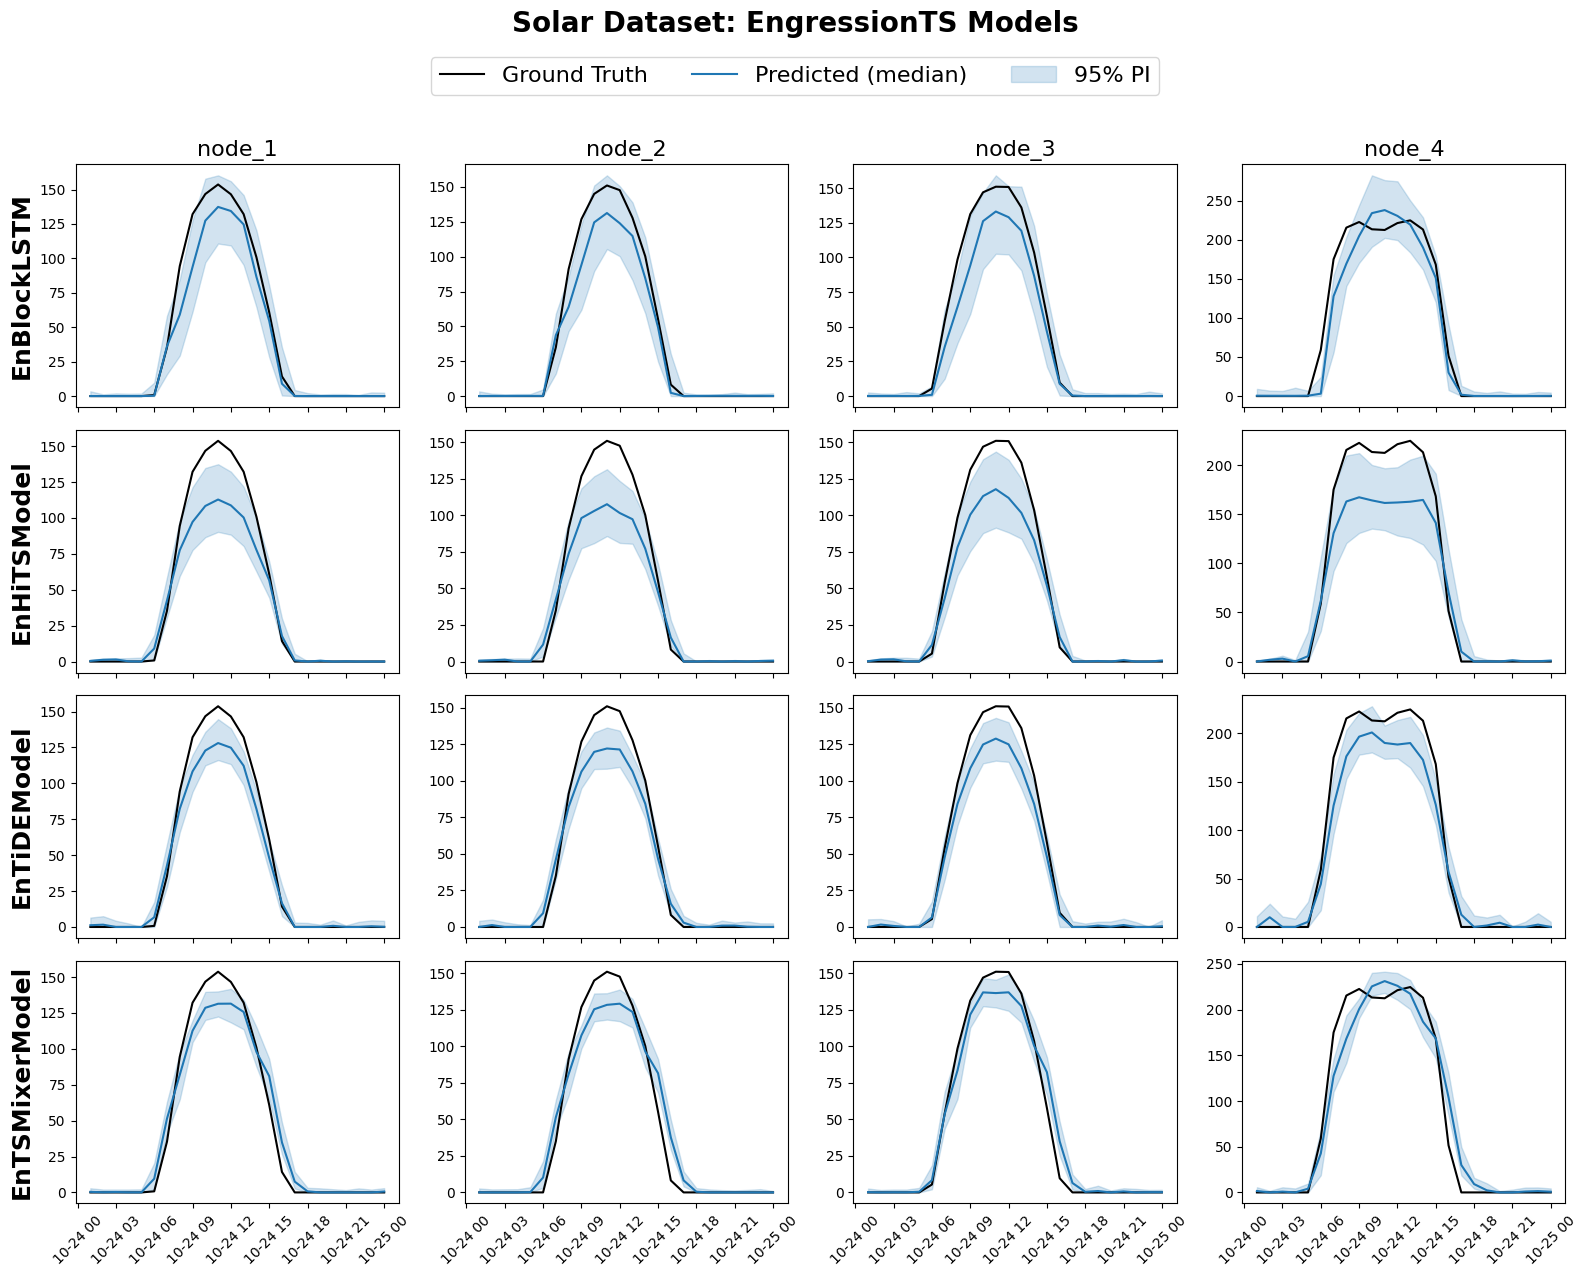

In [49]:
import matplotlib.pyplot as plt

n_rows, n_cols = len(PLOT_MODELS), len(PLOT_NODES)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharex=True
)
axes = np.atleast_2d(axes)

for m_idx, model_name in enumerate(PLOT_MODELS):
    y_true, y_pred, time_index = node_preds_cache[model_name]

    y_median = np.median(y_pred, axis=-1)
    y_lo = np.quantile(y_pred, 0.025, axis=-1)
    y_hi = np.quantile(y_pred, 0.975, axis=-1)

    for n_idx, node_i in enumerate(node_idx):
        ax = axes[m_idx, n_idx]

        ax.plot(
            time_index,
            y_true[:, node_i],
            color="black",
            lw=1.5,
            label="Ground Truth"
        )

        ax.plot(
            time_index,
            y_median[:, node_i],
            color="tab:blue",
            lw=1.5,
            label="Predicted (median)"
        )

        ax.fill_between(
            time_index,
            y_lo[:, node_i],
            y_hi[:, node_i],
            color="tab:blue",
            alpha=0.2,
            label="95% PI"
        )

        if m_idx == 0:
            ax.set_title(
                PLOT_NODES[n_idx],
                fontsize=16
            )

        if n_idx == 0:
            ax.set_ylabel(
                model_name,
                fontsize=18,
                fontweight="bold"
            )

        ax.tick_params(axis="x", rotation=45)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.03),
    fontsize=16
)

fig.suptitle(
    "Solar Dataset: EngressionTS Models",
    y=1.06,
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "Solar_PredVsGT_nodes1-4.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()